# <span style="color:rgb(160,0,86)">Zusammenhangsanalyse</span>

***

## <span style="color:rgb(160,0,86)">Lernziele</span>

- Sie können Zusammenhang in **ordinalen** und **metrischen** Daten analysieren und mit Python graphisch darstellen. 
- Sie kennen den **Korrelationskoeffizienten** und den **Rangkorrelationskoeffizienten**.
- Sie verstehen den Unterschied zwischen **Kausalität** und **Korrelation**.  
    
***

### <span style="color:rgb(160,0,86)">Wie können wir zwei metrische Merkmale graphisch vergleichen?</span>

Zwei **metrische Merkmale** 
$$A = a_1,\, a_2,\, a_3,\, a_4,\,\ldots \;\,\text{ und } \quad B = b_1,\, b_2,\, b_3,\, b_4,\,\ldots $$
können wir **in einem Koordinatensystem** abbilden, indem wir für jede statistische Einheit einen Punkt $$P_1 = (a_1,b_1),\, P_2 = (a_2,b_2),\, P_3 = (a_3,b_3),\, P_4 = (a_4,b_4),\,\ldots$$ mit den Werten des Markmals $A$ als $x$-Koordinate und den Werten des Merkmals $B$ als $y$-Koordinate eintragen. So eine Abbildung heisst **Streudiagramm** oder **Scatterplot**.  

In Python können wir mit der Methode $\,\pmb{\texttt{df.plot.scatter(x = "A", y = "B",...)}}\,$
ein **Streudiagramm** aus einem **pandas DataFrame** $\,\pmb{\texttt{df}}\,$ erstellen.

Um typische Eigenschaften zu demonstrieren, erstellen wir **drei unterschiedliche Datensätze** mit je zwei Merkmalen: $$\begin{array}{c|c} 
\pmb{A} & \pmb{B_p}\\ \hline
a_1 & {(b_p)}_1 \\ 
a_2 & {(b_p)}_2 \\ 
\vdots & \vdots \\
a_{200} & \;\;{(b_p)}_{200}
\end{array} \qquad\quad \begin{array}{c|c} 
\pmb{A} & \pmb{B_n}\\ \hline
a_1 & {(b_n)}_1 \\ 
a_2 & {(b_n)}_2 \\ 
\vdots & \vdots \\
a_{200} & \;\;{(b_n)}_{200}
\end{array}\qquad\quad\begin{array}{c|c} 
\pmb{A} & \pmb{B_u}\\ \hline
a_1 & {(b_u)}_1 \\ 
a_2 & {(b_u)}_2 \\ 
\vdots & \vdots \\
a_{200} & \;\;{(b_u)}_{200}
\end{array}$$ Für das Merkmal $\,\pmb{A}\,$ erzeugen wir **200 uniform zufällige reelle Zahlen zwischen 0 und 15**. Das Merkmal $\,\pmb{B}\,$ unterscheidet sich in den Datensätzen:
- $\;\;\pmb{B_p} \;=\; \big\{\,0.2a + 3 + \textsf{norm(\texttt{loc=0},\texttt{scale=0.8})\,}\;:\;a \in A\big\}\,\rule{0cm}{0.8cm}$
- $\;\;\pmb{B_n} \;=\; \big\{\mathord-1.5a + 14 + \textsf{norm(\texttt{loc=0},\texttt{scale=0.5})\,}\;:\;a \in A\big\}\,\rule{0cm}{1.3cm}$
- $\;\;\pmb{B_u \;}\,\rule{0cm}{1.3cm}$ enthält 200 uniform zufällige Zahlen zwischen 0 und 15   

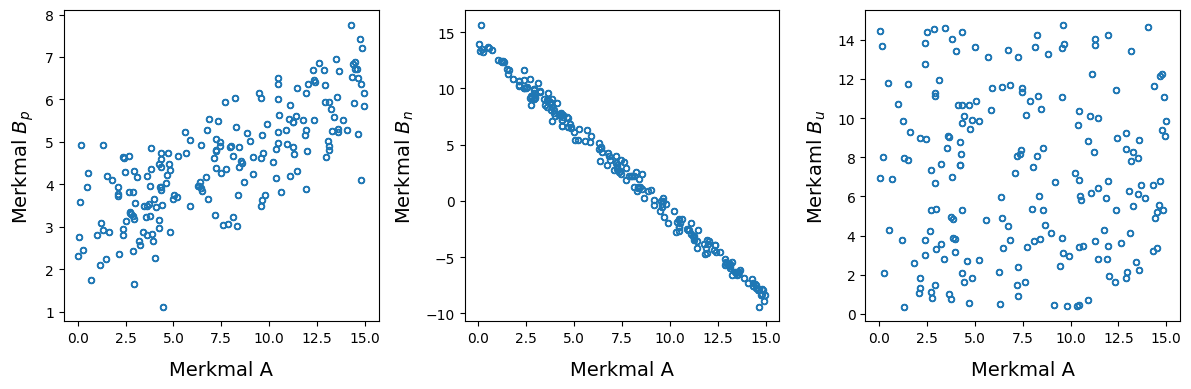

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Daten künstlich erzeugen
A = np.random.uniform(low=0,high=15,size=200)
B_p = 0.2*A + 3 + np.random.normal(0,0.8,200) 
B_n = -1.5*A + 14 + np.random.normal(0,0.5,200)
B_u = np.random.uniform(low=0,high=15,size=200)

# DataFrames erstellen
df_p = pd.DataFrame({"A":A,"B":B_p})
df_n = pd.DataFrame({"A":A,"B":B_n})
df_u = pd.DataFrame({"A":A,"B":B_u})

# Figurobjekt erstellen
fig = plt.figure(figsize=(12,4))

# Streudiagramm für df_p zeichnen
ax1 = fig.add_subplot(1,3,1)
df_p.plot.scatter(x = "A", y = "B", ax = ax1, marker="$\u25EF$")
ax1.set_xlabel("Merkmal A",size=14,labelpad=11)
ax1.set_ylabel(r"Merkmal $B_p$",size=14,labelpad=7)

# Streudiagramm für df_n zeichnen
ax2 = fig.add_subplot(1,3,2)
df_n.plot.scatter(x = "A", y = "B", ax = ax2, marker="$\u25EF$")
ax2.set_xlabel("Merkmal A",size=14,labelpad=11)
ax2.set_ylabel(r"Merkmal $B_n$",size=14,labelpad=7)

# Streudiagramm für df_u zeichnen
ax3 = fig.add_subplot(1,3,3)
df_u.plot.scatter(x = "A", y = "B", ax = ax3, marker="$\u25EF$")
ax3.set_xlabel("Merkmal A",size=14,labelpad=11)
ax3.set_ylabel(r"Merkaml $B_u$",size=14,labelpad=7)

# Figur zeigen
plt.tight_layout()
plt.show()

Der Zusammenhang zwischen zwei ordinalen oder metrischen Merkmalen wird mit unterschiedlichen **Massen** beurteilt. Bei **Korrelationsmassen** wird  die <span style="color:rgb(160,0,86)">***Intensität***</span> als auch die <span style="color:rgb(160,0,86)">***Richtung***</span> des Zusammenhangs gemessen. 

Wir können **positiv korreliert**, **negativ korreliert** und **unkorreliert** unterscheiden:
- **Positive Korrelation** liegt vor, wenn tendentiell gilt: $$\textbf{je gr\"osser } \,\pmb{a_i}\,\textbf{ ist, desto gr\"osser ist auch } \,\pmb{b_i}$$ Zum Beispiel zwischen den Merkmalen $\,\pmb{A}\,$ und $\,\pmb{B_p}\,$.
- **Negative Korrelation** liegt vor, wenn tendentiell gilt:$\rule{0cm}{1.2cm}$ $$\textbf{je gr\"osser } \,\pmb{a_i}\,\textbf{ ist, desto kleiner ist } \,\pmb{b_i}$$ Zum Beispiel zwischen den Merkmalen $\,\pmb{A}\,$ und $\,\pmb{B_n}\,$.
- **keine Korrelation** liegt vor, wenn $\rule{0cm}{1.2cm}$ $$\,\textbf{keine lineare Tendenz vorhanden ist.}\,$$ Zum Beispiel zwischen den Merkmalen $\,\pmb{A}\,$ und $\,\pmb{B_u}\,$.

**Wichtig:** <span style="color:rgb(160,0,86)">***Korrelation beschreibt linare Abhängigkeit***.</span>  
- **Unkorrelierte Merkmale** können eine **andere Abhängigkeit** haben, die nicht linear ist!

In einem **Streudiagramm** wird so eine Tendenz ersichtlich. 

### <span style="color:rgb(160,0,86)">Was machen wir mit sehr grossen Datensätzen?</span>

In **sehr grossen Datensätzen** können sich **Punkte stark überlagern**, so dass wir einen Zusammenhang nicht mehr erkennen! 

Das sehen wir zum Beispiel in den **Immobiliendaten für King County** (Seattle) in Washington USA:
- Merkmal $\,\pmb{A}\,$ ist die **Anzahl fertiggestellter Wohnfläche in Quadratfuss**
- Merkmal $\,\pmb{B}\,$ ist der **steuerlicher Einheitswert**

In [70]:
kc_tax = pd.read_csv("/Users/muellefa/repos/ASTAT/SW10/Daten/kc_tax.csv.gz")
kc_tax.shape

(498249, 3)

In [71]:
kc_tax.head()

,TaxAssessedValue,SqFtTotLiving,ZipCode
0,NaN,1730,98117.0
1,206000.0,1870,98002.0
2,303000.0,1530,98166.0
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0


Auch wenn wir die **Daten in** ***kc_tax*** wie folgt **filtern**, bleibt der Datensatz sehr gross.
- Anzahl fertiggestellter Wohnfläche in $\pmb{[100,3500]}\,$
- steuerlicher Einheitswert in $\,\pmb{[0,750000]}\,$

In [72]:
# DataFrame beschneiden
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), : ]
kc_tax0.shape

(432693, 3)

Im Streudiagramm **erkennen wir keine Tendenz**, weil zu viele **Punkte übereinander liegen**.

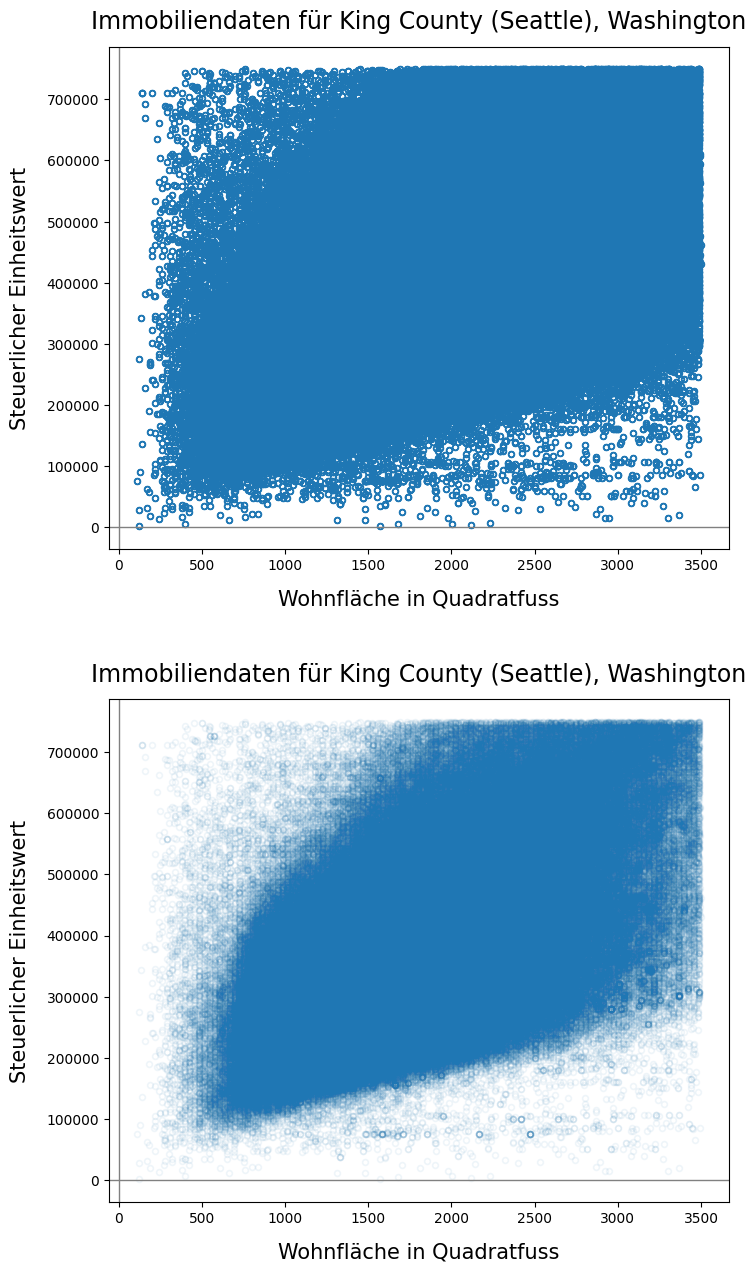

In [73]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(8,15))

# Streudiagramm für "SqFtTotLiving" und "TaxAssessedValue" zeichnen
ax1 = fig.add_subplot(2,1,1)
kc_tax0.plot.scatter(x="SqFtTotLiving",
                     y="TaxAssessedValue",
                     ax= ax1,marker="$\u25EF$")

ax1.set_xlabel("Wohnfläche in Quadratfuss",size=15,labelpad=12)
ax1.set_ylabel("Steuerlicher Einheitswert",size=15,labelpad=12)
ax1.set_title("Immobiliendaten für King County (Seattle), Washington",
              size=17,pad=13)
ax1.axhline(0, color="grey", lw=1)
ax1.axvline(0, color="grey", lw=1)

ax2 = fig.add_subplot(2,1,2)
kc_tax0.plot.scatter(x="SqFtTotLiving",
                     y="TaxAssessedValue",
                     ax= ax2,marker="$\u25EF$",alpha=0.05)

ax2.set_xlabel("Wohnfläche in Quadratfuss",size=15,labelpad=12)
ax2.set_ylabel("Steuerlicher Einheitswert",size=15,labelpad=12)
ax2.set_title("Immobiliendaten für King County (Seattle), Washington",
              size=17,pad=13)
ax2.axhline(0, color="grey", lw=1)
ax2.axvline(0, color="grey", lw=1)

plt.subplots_adjust(hspace=0.3)
plt.show()

Die Funktion <strong><tt>plt.hexbin()</tt></strong> ist eine Plot-Funktion aus **matplotlib**, die zweidimensionale Punktwolken als **hexagonale Bins** darstellt.

**Statt jeden Punkt einzeln zu plotten** (was bei vielen Daten zu Überlagerungen und Unübersichtlichkeit führt), teilt hexbin die Fläche in
-  **regelmässige Sechsecke** ein und **zählt**, **wie viele Punkte in jedes Sechseck fallen**.

Das Ergebnis ist eine <span style="color:rgb(160,0,86)">***dichtebasierte Darstellung mit hexagonalen Zellen***</span>, die die Fläche effizienter und glatter abdecken als quadratische Raster.

Der **Farbton jedes Hexagons** zeigt die Anzahl der Punkte im jeweiligen Bereich. 
- Dadurch werden **Muster**, **Cluster** oder **Bereiche hoher Dichte** in grossen Datensätzen sehr gut sichtbar.


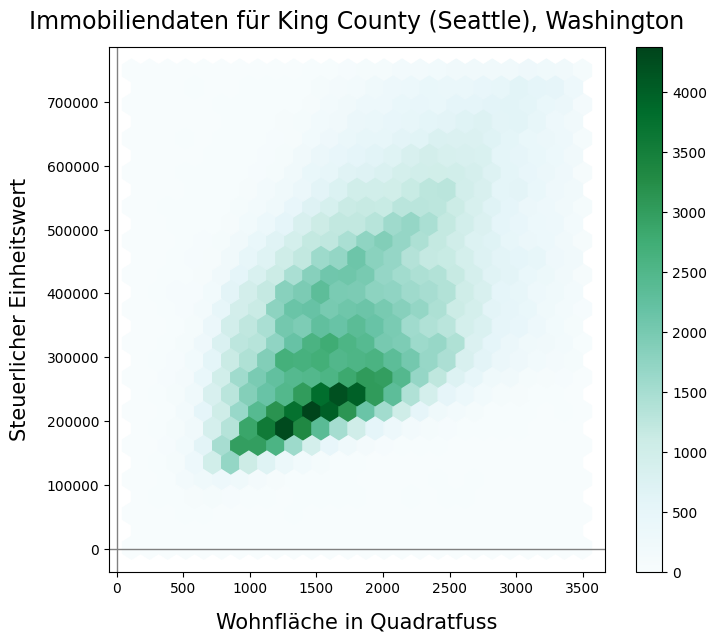

In [74]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(8,15))

# Bienenwabendiagramm für "SqFtTotLiving" und "TaxAssessedValue" zeichnen
axi = fig.add_subplot(2,1,1)

kc_tax0.plot.hexbin(x="SqFtTotLiving",
                    y="TaxAssessedValue",
                    ax=axi,gridsize=25,sharex=False) #hex => sechs

axi.set_xlabel("Wohnfläche in Quadratfuss",size=15,labelpad=12)
axi.set_ylabel("Steuerlicher Einheitswert",size=15,labelpad=12)
axi.set_title("Immobiliendaten für King County (Seattle), Washington",
              size=17,pad=13)
axi.axhline(0, color="grey", lw=1)
axi.axvline(0, color="grey", lw=1)

plt.show()

Die Funktion <strong><tt>sns.kdeplot()</tt></strong> ist eine Funktion aus der **seaborn**-Bibliothek, die eine **Kernel-Dichte-Schätzung** (KDE, Kernel Density Estimation) grafisch darstellt. 

**Anstatt Datenpunkte** direkt anzuzeigen **oder Histogramme** zu verwenden, schätzt KDE eine glatte, **kontinuierliche Wahrscheinlichkeitsdichtefunktion**, die angibt, wie die Werte in einem Datensatz verteilt sind.

- Der zentrale Vorteil von KDE ist, dass sie **nicht von der Wahl der Klassenbreiten** (wie beim Histogramm oder plt.hexbin) **abhängt** und dadurch eine kontinuierlich **geglättet Darstellung der Verteilung** liefert.


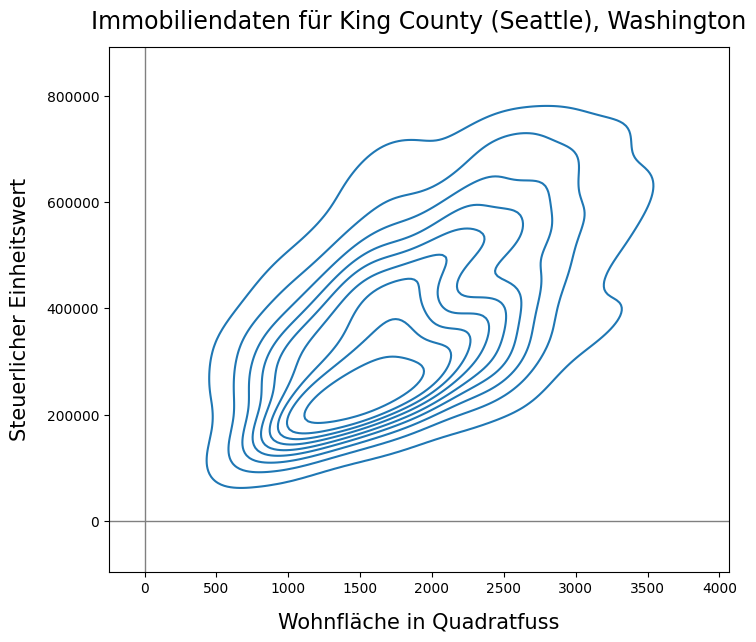

In [75]:
import seaborn as sns

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,15))

# KDE-Schätzung für "SqFtTotLiving" und "TaxAssessedValue" zeichnen
axi = fig.add_subplot(2,1,1)

sns.kdeplot(data=kc_tax0.sample(1000),
            x="SqFtTotLiving",y="TaxAssessedValue",ax=axi)

axi.set_xlabel("Wohnfläche in Quadratfuss",size=15,labelpad=12)
axi.set_ylabel("Steuerlicher Einheitswert",size=15,labelpad=12)
axi.set_title("Immobiliendaten für King County (Seattle), Washington",
              size=17,pad=13)
axi.axhline(0, color="grey", lw=1)
axi.axvline(0, color="grey", lw=1)

plt.show()

<span style="color:rgb(160,0,86)">**KDE als Höhenlinien auf einer Landkarte**</span>

Eine grosse Anzahl von Punkten auf einer Landkarte (z.B. Messwerte, Positionen von Vorkommnissen oder Datenpunkte in einem 2D-Raum) können dicht beieinander oder weit verstreut sein. 

Kernel Density Estimation (KDE) **schätzt** diese ***Dichte*** der Punkte an jeder Position.
- Eine **hohe Dichte** entspricht **hohem Gelände** – viele Punkte konzentrieren sich in diesem Bereich.
- Eine **niedrige Dichte** entspricht **flachem Gelände** – wenige Punkte liegen hier.

Wenn diese Dichte als Konturen oder Farbflächen gezeichnet werden, ähnelt das sehr den **Höhenlinien** auf einer **topografischen Karte**:
- Jede Konturlinie entspricht einem bestimmten Dichtelevel.
- Je enger die Linien beieinander liegen, desto schneller steigt die Dichte, wie steile Berge.
- Flache Bereiche haben weit auseinanderliegende Linien, wie Ebenen.

**2D-KDE-PLOTS** können also als **Dichte-Landschaften** betrachtet werden: 
- hohe Berge zeigen Cluster,
- Täler zeigen dünne Bereiche,
**Muster werden erkennbar**, ohne jeden einzelnen Punkt betrachten zu müssen.

### <span style="color:rgb(160,0,86)">Was ist der Korrelationskoeffizient?</span>

Wie für Lage- und Streumasse können wir auch die **Stärke einer Korrelation messen**. 

Die grundlegende Metrik der Korreklationsanalyse für zwei metrische Merkmale  $A$ und $B$ ist die **Kovarianz**:

$$\sigma_{ab}=\frac{1}{n}\big((a_1-\bar{a})\cdot(b_1-\bar{b})+(a_2-\bar{a})\cdot(b_2-\bar{b})+\ldots+(a_n-\bar{a})\cdot(b_n-\bar{b})\big)$$

Die Kovarianz kann positive und negative Werte annehmen. Das **Vorzeichen** gibt Aufschluss über die **Richtung** des Zusammenhangs:
- Wenn die **Kovarianz** $\pmb{\sigma_{ab}}$ **positiv** ist, gibt es eine **positive Korrelation**.
- Wenn die **Kovarianz** $\pmb{\sigma_{ab}}$ **negativ** ist, gibt es eine **negative Korrelation**.
- Wenn die **Kovarianz** $\pmb{\sigma_{ab}}$ **Null** ist, gibt es keine **Korrelation**.

<span style="color:rgb(160,0,86)">**Bemerkung:**</span> Wenn wir die **Kovarianz** für das Merkmal A **mit sich selbst** berechenen $$\sigma_{aa}=\frac{1}{n}\big((a_1-\bar{a})^2+(a_2-\bar{a})^2+\ldots+(a_n-\bar{a})^2\big)\;,$$
dann entsteht die **mittlere quadratische Abweichung**.

Wir betrachen die Kovarianz für die oben künstlich erzeuten Daten:

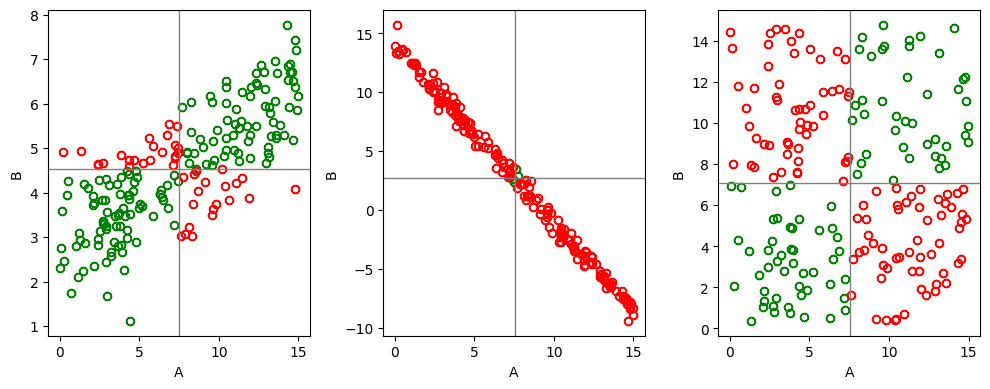

In [76]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(10,4))

''' Streudiagramm für df_p zeichnen '''
ax1 = fig.add_subplot(1,3,1)

# Mittelpunkt berechnen (Mittelwerte)
mean_A = df_p["A"].mean()
mean_B = df_p["B"].mean()

# Positive / negative Kovarianzbereiche
# (d.h. Punkte im selben Quadranten relativ zu den Mittelwerten)
pos_mask = ((df_p["A"] - mean_A) * (df_p["B"] - mean_B)) > 0
neg_mask = ~pos_mask

# Punkte mit positiver Kovarianz (grün)
ax1.scatter(df_p.loc[pos_mask, "A"], df_p.loc[pos_mask, "B"],
            color="green", marker="$\u25EF$")

# Punkte mit negativer Kovarianz (rot)
ax1.scatter(df_p.loc[neg_mask, "A"], df_p.loc[neg_mask, "B"],
            color="red", marker="$\u25EF$")

# Mittelwertslinien
ax1.axvline(mean_A, color="grey", lw=1)
ax1.axhline(mean_B, color="grey", lw=1)

ax1.set_xlabel("A")
ax1.set_ylabel("B")

''' Streudiagramm für df_n zeichnen '''
ax2 = fig.add_subplot(1,3,2)

# Mittelpunkt berechnen (Mittelwerte)
mean_A = df_n["A"].mean()
mean_B = df_n["B"].mean()

# Positive / negative Kovarianzbereiche
# (d.h. Punkte im selben Quadranten relativ zu den Mittelwerten)
pos_mask = ((df_n["A"] - mean_A) * (df_n["B"] - mean_B)) > 0
neg_mask = ~pos_mask

# Punkte mit positiver Kovarianz (grün)
ax2.scatter(df_n.loc[pos_mask, "A"], df_n.loc[pos_mask, "B"],
            color="green", marker="$\u25EF$")

# Punkte mit negativer Kovarianz (rot)
ax2.scatter(df_n.loc[neg_mask, "A"], df_n.loc[neg_mask, "B"],
            color="red", marker="$\u25EF$")

# Mittelwertslinien
ax2.axvline(mean_A, color="grey", lw=1)
ax2.axhline(mean_B, color="grey", lw=1)

ax2.set_xlabel("A")
ax2.set_ylabel("B")

''' Streudiagramm für df_n zeichnen '''
ax3 = fig.add_subplot(1,3,3)

# Mittelpunkt berechnen (Mittelwerte)
mean_A = df_u["A"].mean()
mean_B = df_u["B"].mean()

# Positive / negative Kovarianzbereiche
# (d.h. Punkte im selben Quadranten relativ zu den Mittelwerten)
pos_mask = ((df_u["A"] - mean_A) * (df_u["B"] - mean_B)) > 0
neg_mask = ~pos_mask

# Punkte mit positiver Kovarianz (grün)
ax3.scatter(df_u.loc[pos_mask, "A"], df_u.loc[pos_mask, "B"],
            color="green", marker="$\u25EF$")

# Punkte mit negativer Kovarianz (rot)
ax3.scatter(df_u.loc[neg_mask, "A"], df_u.loc[neg_mask, "B"],
            color="red", marker="$\u25EF$")

# Mittelwertslinien
ax3.axvline(mean_A, color="grey", lw=1)
ax3.axhline(mean_B, color="grey", lw=1)

ax3.set_xlabel("A")
ax3.set_ylabel("B")

# Figur zeigen
plt.tight_layout()
plt.show()

Die Produkte in der **Kovarianz** $$\,\sigma_{ab}=\frac{1}{n}\big((a_1-\bar{a})\cdot(b_1-\bar{b})+\ldots+(a_n-\bar{a})\cdot(b_n-\bar{b})\big)\,$$ sind vom Mittelpunkt $\,\pmb{(\bar{a},\bar{b})}\,$ aus betrachtet für Datenpunkte $\,\pmb{(a_i,b_i)}\,$
- im **1. Quadraten** <span style="color: green">**positiv**</span>, also wenn $\,\textcolor{green}{\pmb{(a_i-\bar{a})>0}}\,$ und $\,\textcolor{green}{\pmb{(b_i-\bar{b})>0}}\,$
- im **2. Quadraten** <span style="color: red">**negativ**</span>, also wenn $\,\textcolor{red}{\pmb{(a_i-\bar{a})<0}}\,$ und $\,\textcolor{red}{\pmb{(b_i-\bar{b})>0}}\,$
- im **3. Quadraten** <span style="color: green">**positiv**</span>, also wenn $\,\textcolor{green}{\pmb{(a_i-\bar{a})<0}}\,$ und $\,\textcolor{green}{\pmb{(b_i-\bar{b})<0}}\,$
- im **4. Quadraten** <span style="color: red">**negativ**</span>, also wenn $\,\textcolor{red}{\pmb{(a_i-\bar{a})>0}}\,$ und $\,\textcolor{red}{\pmb{(b_i-\bar{b})<0}}\,$

In Python können wir mit der Methode $\,\pmb{\texttt{df.cov(ddof = )}}\,$
die **Kovarianzen** aus einem **pandas DataFrame** $\,\pmb{\texttt{df}}\,$ direkt zwischen allen Merkmalen berechnen.

Wie bei der mittleren quadratischen Abweichung und der Standardabweichung müssen wir auch **bei der Kovarianz den Parameter** <strong><tt>ddof</tt></strong> setzen:
- **Bei einer Grundgesamtheit** muss <strong><tt>ddof=0</tt></strong> gesetzt werden, damit $$\dfrac{1}{(n-\pmb{0})}\cdot\big((a_1-\bar{a})(b_1-\bar{b})+(a_2-\bar{a})(b_2-\bar{b})+\ldots+(a_n-\bar{a})(b_n-\bar{b})\big)$$ gerechnet wird.
- Für die **erwartungstreue Sätzung bei einer Stichproben** muss <strong><tt>ddof=1</tt></strong> gesetzt werden, $$\dfrac{1}{(n-\pmb{1})}\cdot\big((a_1-\bar{a})(b_1-\bar{b})+(a_2-\bar{a})(b_2-\bar{b})+\ldots+(a_n-\bar{a})(b_n-\bar{b})\big)$$ gerechnet wird.

In [77]:
# Kovarianzen für df_p
print("Kovarianzen:")
print(df_p.cov(ddof=0),end="\n\n")

# Mittlere quadratische Abweichung für df_p
print("Mittlere quadratische Abweichungen:")
print(" - für A:", df_p["A"].var(ddof=0))
print(" - für B:", df_p["B"].var(ddof=0))

Kovarianzen:
           A         B
A  18.547934  4.128395
B   4.128395  1.574559

Mittlere quadratische Abweichungen:
 - für A: 18.547934497608033
 - für B: 1.5745591254157836


In [78]:
# Kovarianzen für df_n
print("Kovarianzen:")
print(df_n.cov(ddof=0),end="\n\n")

# Mittlere quadratische Abweichung für df_n
print("Mittlere quadratische Abweichungen:")
print(" - für A:", df_n["A"].var(ddof=0))
print(" - für B:", df_n["B"].var(ddof=0))

Kovarianzen:
           A          B
A  18.547934 -27.982139
B -27.982139  42.477237

Mittlere quadratische Abweichungen:
 - für A: 18.547934497608033
 - für B: 42.477237090436695


In [79]:
# Kovarianzen für df_u
print("Kovarianzen:")
print(df_u.cov(ddof=0),end="\n\n")

# Mittlere quadratische Abweichung für df_u
print("Mittlere quadratische Abweichungen:")
print(" - für A:", df_u["A"].var(ddof=0))
print(" - für B:", df_u["B"].var(ddof=0))

Kovarianzen:
           A          B
A  18.547934  -0.359273
B  -0.359273  16.877965

Mittlere quadratische Abweichungen:
 - für A: 18.547934497608033
 - für B: 16.877965423156137


Der absolute Zahlenwert der **Kovarianz** $\pmb{\sigma_{ab}}$ können wir wegen der wenig anschaulichen Dimension und der fehlenden Normierung kaum interpretieren. 
- um eine Aussage über die Intensität der Zusammenhangs machen zu können, muss die Kovarianz mit den Standardabweichungen der beiden Merkmale **normiert werden**.

Der **Korrelationskoeffizient nach Bravais/Pearson** ist die mit den Standardabweichungen von $A$ und $B$ normierte Kovarianz:
$$\pmb{r} =\frac{\pmb{\sigma_{ab}}}{\pmb{\sigma_{a}}\cdot\pmb{\sigma_{b}}}$$ 
Diese Normierung bewirkt, dass der Korrelationskoeffizent **dimensionslos** ist und darüber hinaus gilt:
$$\pmb{-1\leqslant r \leqslant 1}$$

Die Grösse von $\,\pmb{r}\,$ sagt **nichts über die Steigung**. Es gilt nur:
- $\,\pmb{r = 1}\,$ bedeutet, dass alle Punkte **exakt auf einer stigenden Geraden** liegen.
- $\,\pmb{r = 0}\,$ bedeutet, die Punkt **folgen nicht einer Geraden**.
- $\,\pmb{r = -1}\,$ bedeutet, dass alle Punkte **exakt auf einer fallenden Geraden** liegen.

In Python können wir mit der Methode $\,\pmb{\texttt{df.corr()}}\,$
die **Korrelationskoeffizienten** aus einem **pandas DataFrame** $\,\pmb{\texttt{df}}\,$ direkt zwischen allen Merkmalen berechnen.

<span style="color:rgb(160,0,86)">**Bemerkung:**</span> **Beim Korrelationskoeffizient** müssen wir **den Parameter** <strong><tt>ddof</tt></strong> <span style="color: red">**nicht**</span> setzen. Wegen der Division von der Kovarianz mit den beiden Standardabweichungen kürzen sich die Faktoren $$\,\dfrac{1}{n}\quad \text{ bzw. } \quad\dfrac{1}{n-1}$$ im Bruch weg!

In [80]:
df_p.corr()

,A,B
A,1.000000,0.763931
B,0.763931,1.000000


In [81]:
df_n.corr()

,A,B
A,1.000000,-0.996908
B,-0.996908,1.000000


In [82]:
df_u.corr()

,A,B
A,1.000000,-0.020306
B,-0.020306,1.000000


Mit dem Korrelationskoeffizient können wir die **Korrelation der Immobiliendaten für King County** messen:

In [83]:
kc_tax0[["SqFtTotLiving","TaxAssessedValue"]].corr()

,SqFtTotLiving,TaxAssessedValue
SqFtTotLiving,1.000000,0.531024
TaxAssessedValue,0.531024,1.000000


Der **Korrelatioinskoeffizient** $\,\pmb{r \approx 0.53}\,$ zeigt einen **moderaten positiven linearen Zusammenhang**.

<span style="color:rgb(160,0,86)">***Achtung:***</span> Merkmale können einen **nicht linearen Zusammenhang** haben. In so einem Fall ist der Korrelationskoeffizient möglicherweise nicht aussagekräftig!
- <span style="color:rgb(160,0,86)">***Der Korrelationskoeffizient misst nur Linearität!***</span>

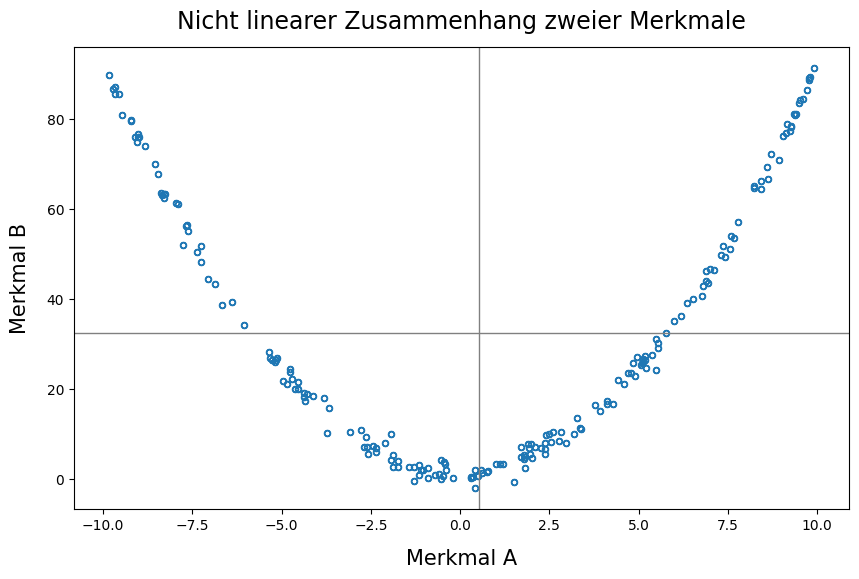

In [84]:
# Daten künstlich erzeugen
A = np.random.uniform(low=-10,high=10,size=200)
B = 0.9*A**2 + 2 + np.random.normal(0,1.5,200) 

# DataFrames für A mit B erstellen
df = pd.DataFrame({"A":A,"B":B})

# Figurobjekt erstellen
fig = plt.figure(figsize=(10,6))

# Streudiagramm zeichnen
axi = fig.add_subplot(1,1,1)
df.plot.scatter(x = "A", y = "B", ax = axi,marker="$\u25EF$")

axi.set_xlabel("Merkmal A",size=15,labelpad=12)
axi.set_ylabel("Merkmal B",size=15,labelpad=12)
axi.axvline(df["A"].mean(), color="grey", lw=1)
axi.axhline(df["B"].mean(), color="grey", lw=1)
axi.set_title("Nicht linearer Zusammenhang zweier Merkmale",
              size=17,pad=13)

# Figur zeigen
plt.show()

In [85]:
df.corr()

,A,B
A,1.000000,0.057371
B,0.057371,1.000000


### <span style="color:rgb(160,0,86)">Wie messen wir Korrelation bei ordinalen Merkmalen?</span>

Die **Kovarianz** $\pmb{\sigma_{ab}}$ und der darauf basierende **Korrelationskeffizient** $\pmb{r}$ **nach Bravais/Pearson** setzen voraus, dass die Merkmale, deren Zusammenhang untersucht wird, **metrisch** sind. Wir müssen mit den Werten rechnen können!

Ist hingegen **zumindest eines der beiden Merkmale nur ordinal**, so wird stattdessen der **Rangkorreklationskoeffizient nach Spearman** verwendet. In diesem Fall werden den Werten $a_1,a_2,a_3,\ldots,a_n$ und $b_1,b_2,b_3,\ldots,b_n$ sogenannte **Rangzahlen** $$\pmb{R(a_i)} \;\text{ und }\; \pmb{R(b_i)}$$ zugewiessen:
- **der kleinste** $a_i$-Wert bzw. $b_i$-Wert erhält die **Rangzahl 1**,
- **der zweitkleinste** $a_i$-Wert bzw. $b_i$-Wert erhält die **Rangzahl 2**,
- usw.
- **der grösste** $a_i$-Wert bzw. $b_i$-Wert erhält die **Rangzahl** $\pmb{n}$.

Wenn mehrere Werte eines Merkmals gleich gross sind (man spricht von **Bindungen**), erhalten diese alle **als Rangzahl das arithmetische Mittel** der betreffenden Rangzahlen. 

Betrachten wir zum die folgenden Werte: $$\begin{array}{cccccccccc}
\tiny\pmb{\texttt{"gen\"ugend"}},&\!\!\!\!
\tiny\pmb{\texttt{"gut"}},&\!\!\!\!
\tiny\pmb{\texttt{"gut"}},&\!\!\!\!
\tiny\pmb{\texttt{"gut"}},&\!\!\!\!
\tiny\pmb{\texttt{"gut"}},&\!\!\!\!
\tiny\pmb{\texttt{"gut"}},&\!\!\!\!
\tiny\pmb{\texttt{"gut"}},&\!\!\!\!
\tiny\pmb{\texttt{"sehr gut"}},&\!\!\!\!
\tiny\pmb{\texttt{"sehr gut"}},&\!\!\!\!
\tiny\pmb{\texttt{"ausgezeichnet"}}\\
1&2&3&4&5&6&7&8&9&10\\
1&\textcolor{red}{4.5}&\textcolor{red}{4.5}&\textcolor{red}{4.5}&\textcolor{red}{4.5}&\textcolor{red}{4.5}&\textcolor{red}{4.5}&\textcolor{red}{8.5}&\textcolor{red}{8.5}&10\end{array}$$

Der **Rangkorrelationskoeffizient** erhält man nun einfach, indem man den Korrelationskoeffizienten nach Bravais/Pearson auf die Rangzahlen anwendet: $$\pmb{r_{Sp}=\frac{\sigma_{R(a)R(b)}}{\sigma_{R(a)}\cdot\sigma_{R(b)}}}\;.$$

### <span style="color:rgb(160,0,86)">Was bedeutet Kausalität?</span>

Wenn wir in Daten eine statistische Beziehung zwischen zwei Merkmalen feststellen, heisst das noch nicht, dass in der Tat ein **kausaler Zusammenhang** besteht. 
- **Kausalität** ist ein **Ursache-Wirkungs-Zusammenhang** (Feuer verursacht Wärme)
- **Korrelation** ist ein **statistischer Zusammenhang** (Eisverkauf und Sonnenbrand steigen gemeinsam im Sommer) 


Im folgenden *Datensatz* ist der **durchschnittlicher Weinkonsum** (in Liter pro Person und Jahr) und die **Mortalität** (Anzahl Todesfälle pro 1000 Personen zwischen 55 und 64 Jahren pro Jahr) aufgrund von Herz- und Kreislauferkrankungen in 18 Ländern erfasst:
$$\begin{array}{l|cc}
\text{Land} & \text{Weinkonsum} & \text{Mortalität Herzerkrankung} \\ \hline
\text{Norwegen} & 2.8 & 6.2 \\
\text{Schottland} & 3.2 & 9.0 \\
\text{Grossbritannien} & 3.2 & 7.1 \\
\text{Irland} & 3.4 & 6.8 \\
\text{Finnland} & 4.3 & 10.2 \\
\text{Kanada} & 4.9 & 7.8 \\
\text{Vereinigte Staaten} & 5.1 & 9.3 \\
\text{Niederlande} & 5.2 & 5.9 \\
\text{New Zealand} & 5.9 & 8.9 \\
\text{Dänemark} & 5.9 & 5.5 \\
\text{Schweden} & 6.6 & 7.1 \\
\text{Australien} & 8.3 & 9.1 \\
\text{Belgien} & 12.6 & 5.1 \\
\text{Deutschland} & 15.1 & 4.7 \\
\text{Österreich} & 25.1 & 4.7 \\
\text{Schweiz} & 33.1 & 3.1 \\
\text{Italien} & 75.9 & 3.2 \\
\text{Frankreich} & 75.9 & 2.1
\end{array}$$

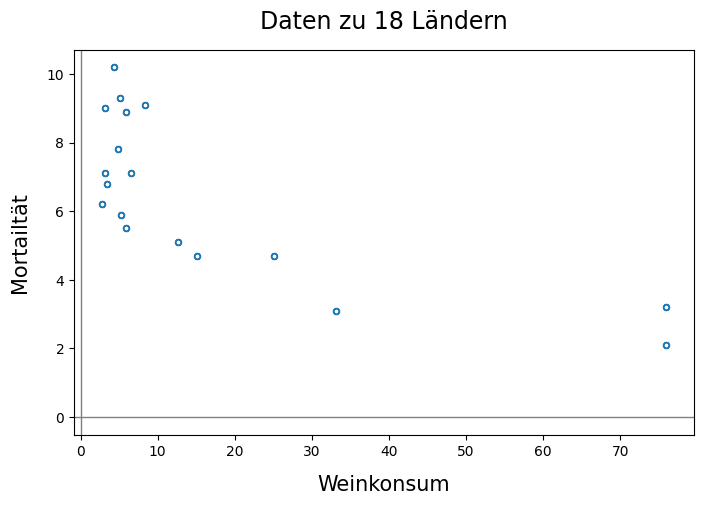

In [86]:
# Daten speichern
Weinkonsum = np.array([2.8,3.2,3.2,3.4,4.3,4.9,5.1,5.2,5.9,5.9,6.6,8.3,12.6,15.1,25.1,33.1,75.9,75.9])
Mortalität = np.array([6.2,9.0,7.1,6.8,10.2,7.8,9.3,5.9,8.9,5.5,7.1,9.1,5.1,4.7,4.7,3.1,3.2,2.1])

# DataFrame erstellen
df = pd.DataFrame({"Weinkonsum":Weinkonsum,"Mortalität":Mortalität})

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,5))

# Streudiagramm für "Weinkonsum" und "Mortalität" zeichnen
axi = fig.add_subplot(1,1,1)
df.plot.scatter(x="Weinkonsum",
                y="Mortalität",
                ax = axi,marker="$\u25EF$")
axi.set_xlabel("Weinkonsum",size=15,labelpad=12)
axi.set_ylabel("Mortailtät",size=15,labelpad=12)
axi.set_title("Daten zu 18 Ländern",size=17,pad=15)
axi.axhline(0, color="grey", lw=1)
axi.axvline(0, color="grey", lw=1)

plt.show()

In [87]:
df.corr()

,Weinkonsum,Mortalität
Weinkonsum,1.000000,-0.745568
Mortalität,-0.745568,1.000000


Der **Korrelatioinskoeffizient** $\,\pmb{r \approx -0.75}\,$ zeigt einen **moderaten negativen linearen Zusammenhang**.
- Auch wenn die Daten eine negative Tendenz zeigen, heisst das nicht, dass ein hoher Weinkonsum wirklich zu einer niedrigeren Sterblichkeit führt. Möglicherweise spielt ein anderes Merkmal eine Rolle – zum Beispiel Olivenölkonsum, Vitamin-D oder andere Einflüsse, die in südlicheren Ländern häufiger vorkommen.

***

**Geysir Old Faithful** (Yellowstone National Park) ist eine bekannte heisse Quelle. Für Zuschauer und Nationalparkdienst ist die Zeitspanne zwischen
zwei Ausbrüchen und die Eruptionsdauer von grossem Interesse.

Von 1.8.1978 - 8.8.1978 wurden insgesamt 107 Messungen von
**aufeinanderfolgenden Ausbrüchen** gemacht:

In [88]:
geysir = pd.read_csv("/Users/muellefa/repos/ASTAT/SW10/Daten/geysir.dat",delimiter=" ")
geysir.head()

,Tag,Zeitspanne,Eruptionsdauer
1,1,78,4.4
2,1,74,3.9
3,1,68,4.0
4,1,76,4.0
5,1,80,3.5


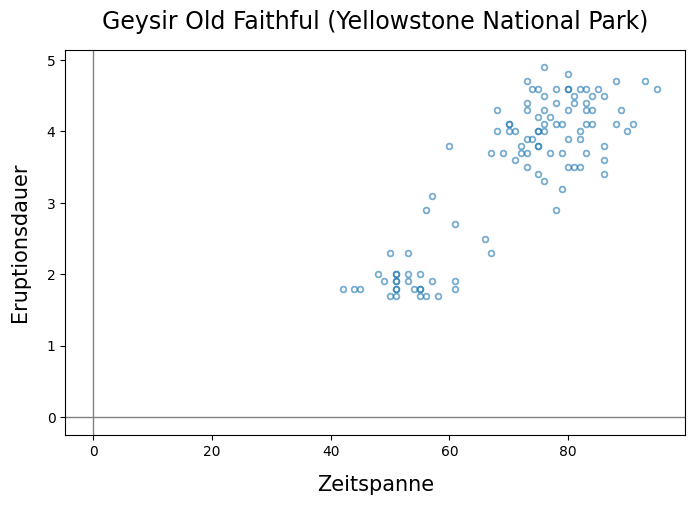

In [89]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(8,5))

# Streudiagramm für "Zeitspanne" und "Eruptionsdauer" zeichnen
axi = fig.add_subplot(1,1,1)
geysir.plot.scatter(x="Zeitspanne",
                    y="Eruptionsdauer",
                    ax=axi,marker="$\u25EF$",alpha=0.5)
axi.set_xlabel("Zeitspanne",size=15,labelpad=12)
axi.set_ylabel("Eruptionsdauer",size=15,labelpad=12)
axi.set_title("Geysir Old Faithful (Yellowstone National Park)",
              size=17,pad=15)
axi.axhline(0, color="grey", lw=1)
axi.axvline(0, color="grey", lw=1)

plt.show()

In [90]:
geysir[["Zeitspanne","Eruptionsdauer"]].corr()

,Zeitspanne,Eruptionsdauer
Zeitspanne,1.000000,0.858427
Eruptionsdauer,0.858427,1.000000


Der **Korrelatioinskoeffizient** $\,\pmb{r \approx 0.85}\,$ zeigt einen **moderaten positiven linearen Zusammenhang**.
- Ein positiver linearer Zusammenhang zwischen ***Zeitspanne*** und ***Eruptionsdauer*** ist plausibel, da geophysikalische Eigenschaften auf einen kausalen Zusammenhang hinweisen.

### <span style="color:rgb(160,0,86)">Beispiel: Börsendaten</span>

Wir machen eine **Zusammenhangsanalyse** für die **Tagesrenditen von Aktien** von Juli 2012 bis Juni 2015 der Telekommunikationsbranche :

In [91]:
import pandas as pd
sp500_sym = pd.read_csv("/Users/muellefa/repos/ASTAT/SW10/Daten/sp500_sectors.csv")
sp500_px = pd.read_csv("/Users/muellefa/repos/ASTAT/SW10/Daten/sp500_data.csv.gz")

print(sp500_sym.shape,sp500_px.shape)

(517, 4) (5647, 518)


In [92]:
sp500_px.set_index("Unnamed: 0",inplace=True)

In [93]:
telecomSym = sp500_sym[sp500_sym["sector"] == 
                       "telecommunications_services"]["symbol"]
telecomSym

332       T
333     CTL
334     FTR
335      VZ
336    LVLT
Name: symbol, dtype: object

In [94]:
telecom = sp500_px.loc[sp500_px.index >= "2012-07-01"]
telecom.head()

,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,ALTR,...,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
2012-07-02,1.190002,-0.224999,-0.055103,-0.560002,-0.455000,-0.104774,-0.279545,-0.495967,-0.018692,-0.152205,...,-0.970001,3.830002,1.257135,0.0,2.110001,0.105000,0.219207,5.610000,-0.539997,-0.189994
2012-07-03,0.440002,0.125998,0.486724,0.849998,0.165001,0.219071,0.308464,0.439807,0.093461,0.409055,...,1.090004,-0.510002,1.058641,0.0,0.100006,0.440002,0.274009,1.300003,-0.170002,0.519997
2012-07-05,-0.369995,-0.116998,0.101019,0.459999,0.395001,-0.038100,-0.269906,0.383662,0.186922,-0.475645,...,0.690003,-0.489998,0.255211,0.0,-0.600006,-0.175003,-0.283971,-0.630005,0.000000,0.369995
2012-07-06,0.319992,-0.476996,-0.385706,-2.159999,-0.920000,-0.523868,-0.279546,-2.348823,0.074769,-0.742004,...,-1.330001,-1.980003,-0.396989,0.0,-1.569992,-0.170002,-0.254081,-0.659996,-0.869999,-0.970002
2012-07-09,-0.070007,-0.152999,-0.110203,-1.880001,-0.139999,-0.114299,-0.279544,-1.020006,-0.084115,-0.494672,...,-1.029999,-0.599999,0.680554,0.0,0.220002,0.069999,0.194296,-2.349998,-1.310002,-0.350006


In [95]:
telecom = telecom[telecomSym]
telecom.head()

,T,CTL,FTR,VZ,LVLT
Unnamed: 0,,,,,
2012-07-02,0.422496,0.140847,0.070879,0.554180,-0.519998
2012-07-03,-0.177448,0.066280,0.070879,-0.025976,-0.049999
2012-07-05,-0.160548,-0.132563,0.055128,-0.051956,-0.180000
2012-07-06,0.342205,0.132563,0.007875,0.140106,-0.359999
2012-07-09,0.136883,0.124279,-0.023626,0.253943,0.180000


In [96]:
telecom.corr()

,T,CTL,FTR,VZ,LVLT
T,1.000000,0.474683,0.327767,0.677612,0.278626
CTL,0.474683,1.000000,0.419757,0.416604,0.286665
FTR,0.327767,0.419757,1.000000,0.287386,0.260068
VZ,0.677612,0.416604,0.287386,1.000000,0.242199
LVLT,0.278626,0.286665,0.260068,0.242199,1.000000


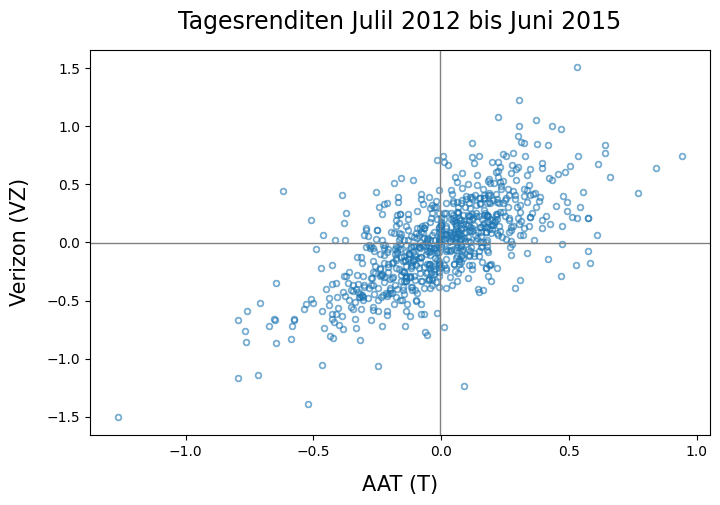

In [97]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(8,5))

# Streudiagramm für T und VZ zeichnen
axi = fig.add_subplot(1,1,1)
telecom.plot.scatter(x="T",y="VZ",
                    ax=axi,marker="$\u25EF$",alpha=0.5)

axi.set_title("Tagesrenditen Julil 2012 bis Juni 2015",size=17,pad=15)
axi.set_xlabel("AAT (T)",size=15,labelpad=12)
axi.set_ylabel("Verizon (VZ)",size=15,labelpad=12)
axi.axhline(telecom["VZ"].mean(), color="grey", lw=1)
axi.axvline(telecom["T"].mean(), color="grey", lw=1)

plt.show()

Nun analysieren wir die **Tagesrenditen** der wichtigsten börsengehandelten **Indexfonds (ETFs)**:  

In [98]:
etfSym = sp500_sym[sp500_sym["sector"] == "etf"]["symbol"]
etfSym

315    XLI
316    QQQ
317    SPY
318    DIA
319    GLD
320    VXX
321    USO
322    IWM
323    XLE
324    XLY
325    XLU
326    XLB
327    XTL
328    XLV
329    XLP
330    XLF
331    XLK
Name: symbol, dtype: object

In [99]:
etfs = sp500_px.loc[sp500_px.index >= "2012-07-01",etfSym]
etfs.head()

,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
Unnamed: 0,,,,,,,,,,,,,,,,,
2012-07-02,-0.376098,0.096313,0.028223,-0.242796,0.419998,-10.40,0.000000,0.534641,0.028186,0.095759,0.098311,-0.093713,0.019076,-0.009529,0.313499,0.018999,0.075668
2012-07-03,0.376099,0.481576,0.874936,0.728405,0.490006,-3.52,0.250000,0.926067,0.995942,0.000000,-0.044686,0.337373,0.000000,0.000000,0.129087,0.104492,0.236462
2012-07-05,0.150440,0.096313,-0.103487,0.149420,0.239991,6.56,-0.070000,-0.171848,-0.460387,0.306431,-0.151938,0.103086,0.019072,-0.142955,-0.073766,-0.142490,0.066211
2012-07-06,-0.141040,-0.491201,0.018819,-0.205449,-0.519989,-8.80,-0.180000,-0.229128,0.206706,0.153214,0.080437,0.018744,-0.429213,-0.095304,0.119865,0.066495,-0.227003
2012-07-09,0.244465,-0.048160,-0.056445,-0.168094,0.429992,-0.48,0.459999,-0.190939,-0.234892,-0.201098,-0.035751,-0.168687,0.000000,0.352630,-0.064548,0.018999,0.009457


In [100]:
etfs.corr()

,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
XLI,1.000000,0.785865,0.888865,0.869680,0.056554,-0.468196,0.236881,0.782380,0.650054,0.798080,0.380809,0.784144,0.374000,0.663022,0.600424,0.787340,0.777773
QQQ,0.785865,1.000000,0.908995,0.834440,0.043553,-0.470555,0.199492,0.810158,0.560044,0.839701,0.346667,0.713463,0.421790,0.775392,0.614806,0.752771,0.945126
SPY,0.888865,0.908995,1.000000,0.953726,0.078722,-0.547074,0.272069,0.833937,0.713300,0.887028,0.481928,0.826053,0.406181,0.811269,0.744466,0.883616,0.886588
DIA,0.869680,0.834440,0.953726,1.000000,0.051523,-0.511327,0.256793,0.758012,0.658311,0.847043,0.463364,0.787415,0.383928,0.771044,0.753725,0.860556,0.842757
GLD,0.056554,0.043553,0.078722,0.051523,1.000000,-0.107488,0.216563,0.070110,0.188625,0.017467,0.121611,0.184366,-0.042233,-0.010200,0.033047,0.043039,0.053022
VXX,-0.468196,-0.470555,-0.547074,-0.511327,-0.107488,1.000000,-0.195397,-0.448942,-0.448474,-0.474756,-0.260395,-0.470890,-0.205661,-0.380925,-0.416913,-0.514365,-0.477258
USO,0.236881,0.199492,0.272069,0.256793,0.216563,-0.195397,1.000000,0.249799,0.525943,0.183275,0.113182,0.324166,0.078796,0.119500,0.116857,0.221760,0.225962
IWM,0.782380,0.810158,0.833937,0.758012,0.070110,-0.448942,0.249799,1.000000,0.586991,0.779750,0.325003,0.701533,0.387274,0.664288,0.537065,0.756282,0.760438
XLE,0.650054,0.560044,0.713300,0.658311,0.188625,-0.448474,0.525943,0.586991,1.000000,0.578956,0.337942,0.689778,0.260463,0.454457,0.413486,0.599129,0.559324
XLY,0.798080,0.839701,0.887028,0.847043,0.017467,-0.474756,0.183275,0.779750,0.578956,1.000000,0.366827,0.721232,0.370299,0.702860,0.663055,0.782053,0.772189


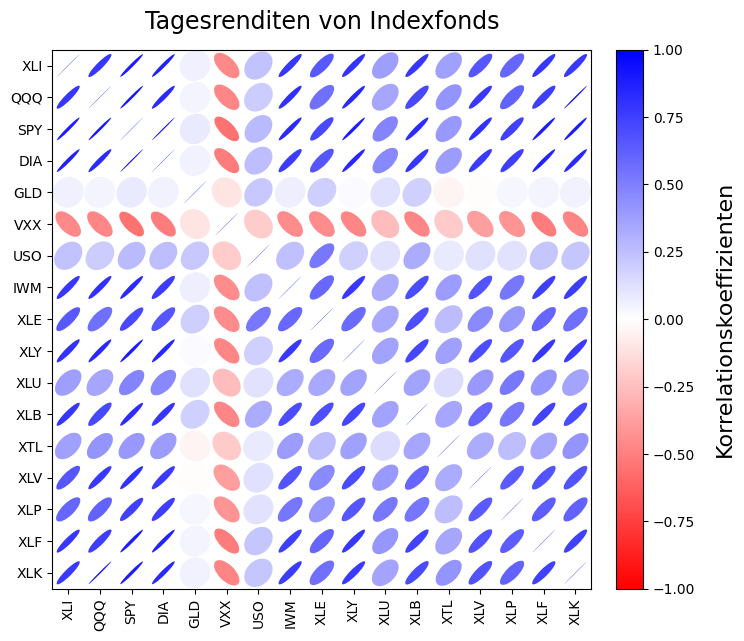

In [101]:
from matplotlib.collections import EllipseCollection
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

M = np.array(etfs.corr())

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,7))

# Streudiagramm für Tagesrenditen von Indexfonds
axi = fig.add_subplot(1,1,1)
axi.set_aspect("equal")

axi.set_xlim(-0.5, M.shape[1]-0.5)
axi.set_ylim(-0.5, M.shape[0]-0.5)
axi.invert_yaxis()

#Koordinatenpaare für die Ellipsen erstellen
xy = np.array([[i,j] for j in range(M.shape[0]) for i in range(M.shape[1])])

#Ellipsen Abmessungen
w = np.ones_like(M).ravel() + 0.01 # ravel : entwirren -> in einen 1-dim array
h = 1 - np.abs(M).ravel() -0.01
a = 45 * np.sign(M).ravel()

#Ellipsen erstellen
ec = EllipseCollection(widths = w,
                      heights = h,
                      angles = a,
                      units = "x",
                      offsets = xy,
                      norm=Normalize(vmin=-1,vmax=1),
                      transOffset = axi.transData,
                      array = M.ravel(),
                      cmap="bwr_r")

axi.add_collection(ec)
axi.set_title("Tagesrenditen von Indexfonds",size=17,pad=15)
axi.set_xticks(np.arange(M.shape[1]))
axi.set_xticklabels(etfs,rotation=90)
axi.set_yticks(np.arange(M.shape[1]))
axi.set_yticklabels(etfs)

fig.colorbar(ec,ax=axi,orientation="vertical",
             fraction=0.046,pad=0.04).set_label(
             label="Korrelationskoeffizienten",size=16,labelpad=14)

plt.show()

### <span style="color:rgb(160,0,86)">Aufgabe 1</span>
Machen Sie eine **Zusammenhangsanalyse** für die Daten der Hünereier im Datensatz *Palette.sav*.

In [102]:
# To do!

### <span style="color:rgb(160,0,86)">Aufgabe 2</span>

Machen Sie eine **Zusammenhangsanalyse** für die Daten der *palmerpenguins* (siehe Serie 03).

In [103]:
# To do!

### <span style="color:rgb(160,0,86)">Aufgabe 3</span>

Ergänzen Sie die **Zusammenhangsanalyse** der Aufgabe 2 im Datensatz *2021_Personalerhebung.csv* für die anderen Merkmale.

In [104]:
# To do!

![HSLU](Bilder/LogoHSLU.png)